# Gamma-Constrained Black–Scholes Model

This notebook implements and studies the **Black–Scholes model with a Gamma constraint**

We work with a risk-free asset $S^0$ and a risky asset $S$:

$$
\begin{aligned}
dS^0_t &= r\, S^0_t\, dt, \\
dS_t &= S_t \bigl(\mu\, dt + \sigma(t,S_t)\, dB_t\bigr).
\end{aligned}
$$

In the classical Black–Scholes setting, the hedging strategy is the Delta  
$$
Y_t = \frac{\partial v}{\partial s}(t,S_t).
$$

Here we impose a **Gamma constraint**:
$$
s\, v_{ss}(t,s) \le \Gamma.
$$

The option price $v$ is the viscosity solution of the variational inequality:
$$
\min\Bigl(
- v_t
- \tfrac12 \sigma^2(t,s)\, s^2\, v_{ss}
- r s v_s
+ r v,\;
\Gamma - s v_{ss}
\Bigr) = 0,
\qquad v(T,s) = \hat g(s).
$$

The terminal condition $\hat g$ is the **smallest function above the payoff $g$**
that satisfies the curvature constraint $s\,\hat g''(s) \le \Gamma$.
This is called the **$\Gamma$-concave envelope** of $g$.


In [3]:
import os
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt

## 1. Question 1 — Terminal Condition $\hat g$ for a Put with Gamma Constraint

We first consider the **European put payoff**:

$$
g(S) = (K - S)^+.
$$

The terminal condition $\hat g$ is defined as the **smallest** function such that:

- $\hat g(S) \ge g(S)$ for all $S > 0$,
- $S\,\hat g''(S) \le \Gamma$ for all $S > 0$.

Equivalently, $\hat g$ solves the static variational inequality:
$$
\min\bigl(\hat g(S) - g(S),\; \Gamma - S\hat g''(S)\bigr) = 0,
\qquad S > 0.
$$


### 1.1 Dimensionless reduction and analytic form

Introduce the dimensionless variable  
$$
x = \frac{S}{K}, 
\qquad 
\varphi(x) = \frac{\hat g(S)}{K}.
$$

Then the put payoff becomes  
$$
g(S) = (K - S)^+ 
\quad\Longleftrightarrow\quad
(1 - x)^+ = \frac{g(S)}{K}.
$$

The Gamma constraint reads  
$$
S\,\hat g''(S) \le \Gamma
\quad\Longleftrightarrow\quad
x\,\varphi''(x) \le \Gamma.
$$

One can prove that there exist two free boundaries  
$$
0 < \alpha < 1 < \beta
$$
such that the solution has the piecewise form  
$$
\varphi(x)=
\begin{cases}
1 - x, & x \le \alpha,\\[6pt]
\Gamma(x\ln x - x) + C_1 x + C_2, & \alpha < x < \beta,\\[6pt]
0, & x \ge \beta,
\end{cases}
$$
where the middle region corresponds to **saturation of the Gamma constraint**:  
$$
x\,\varphi''(x) = \Gamma 
\quad\Longrightarrow\quad 
\varphi''(x) = \Gamma/x.
$$

Imposing **value and slope continuity** at the boundaries,
$$
\begin{aligned}
\varphi(\alpha) &= 1-\alpha, &\qquad \varphi'(\alpha) &= -1,\\[6pt]
\varphi(\beta) &= 0,         &\qquad \varphi'(\beta) &= 0,
\end{aligned}
$$
leads to explicit expressions for $\alpha$, $\beta$, $C_1$, $C_2$ depending only on $\Gamma$:  
$$
\alpha = \frac{1}{\Gamma\bigl(e^{1/\Gamma} - 1\bigr)},
\qquad
\beta = \alpha\,e^{1/\Gamma},
$$
and  
$$
C_1 = -1 - \Gamma \ln \alpha, 
\qquad
C_2 = \Gamma \alpha + 1.
$$

Therefore, for any $S>0$,  
$$
\hat g(S) = K\,\varphi(S/K).
$$


In [7]:
def gamma_put_alpha_beta(Gamma: float):
    """Closed-form dimensionless free boundaries (alpha, beta) for the Gamma-constrained put."""
    alpha = 1.0 / (Gamma * (mp.e**(1.0 / Gamma) - 1.0))
    beta = alpha * mp.e**(1.0 / Gamma)
    return float(alpha), float(beta)


def hat_g_put_analytic(S: float, K: float, Gamma: float) -> float:
    """Analytic terminal condition \\hat g(S) for a Gamma-constrained put."""
    if S <= 0:
        # Limit as S -> 0
        return K

    alpha, beta = gamma_put_alpha_beta(Gamma)
    x = S / K

    if x <= alpha:
        return K - S
    if x >= beta:
        return 0.0

    C1 = -1.0 - Gamma * mp.log(alpha)
    C2 = Gamma * alpha + 1.0
    phi = Gamma * (x * mp.log(x) - x) + C1 * x + C2
    return float(K * phi)


Figure saved to: figures\gamma_constrained_put_K100.0_Gamma1.0.png


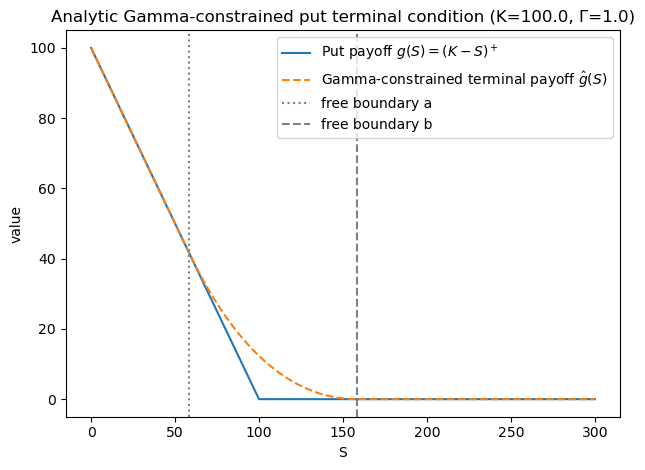

In [9]:

# ---- Parameters ----
K = 100.0
Gamma = 1.0

S_min, S_max = 1e-4, 3.0 * K
S_grid = np.linspace(S_min, S_max, 400)

# Payoff and constrained payoff
g_put = np.maximum(K - S_grid, 0.0)
hatg_put = np.array([hat_g_put_analytic(S, K, Gamma) for S in S_grid])

# Free boundaries
alpha, beta = gamma_put_alpha_beta(Gamma)
a, b = alpha * K, beta * K

# ---- Create figure directory ----
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

# ---- Plot ----
plt.figure()
plt.plot(S_grid, g_put, label=r"Put payoff $g(S)=(K-S)^+$")
plt.plot(S_grid, hatg_put, '--', label=r"Gamma-constrained terminal payoff $\hat g(S)$")
plt.axvline(a, color='grey', linestyle=':', label='free boundary a')
plt.axvline(b, color='grey', linestyle='--', label='free boundary b')
plt.xlabel("S")
plt.ylabel("value")
plt.title(f"Analytic Gamma-constrained put terminal condition (K={K}, Γ={Gamma})")
plt.legend()
plt.tight_layout()

# ---- Save figure ----
save_path = os.path.join(save_dir, f"gamma_constrained_put_K{K}_Gamma{Gamma}.png")
plt.savefig(save_path, dpi=300)
print(f"Figure saved to: {save_path}")

plt.show()

### 1.2 Free-boundary formulation and Newton's method

The analytic solution can also be recovered by treating  
$(\alpha, \beta, C_1, C_2)$ as **unknowns** and solving a system of four nonlinear equations:

$$
\begin{aligned}
F_1 &= \varphi(\alpha) - (1-\alpha) = 0, \\[6pt]
F_2 &= \varphi'(\alpha) + 1 = 0, \\[6pt]
F_3 &= \varphi(\beta) = 0, \\[6pt]
F_4 &= \varphi'(\beta) = 0,
\end{aligned}
$$

where the middle-region expression of $\varphi$ is

$$
\varphi(x) = \Gamma(x\ln x - x) + C_1 x + C_2,
\qquad
\varphi'(x) = \Gamma \ln x + C_1.
$$

**Newton’s method** offers a numerical check of the analytic solution


In [12]:
def F_free_boundary(z, Gamma: float):
    """Nonlinear system F(z)=0 for z=(alpha, beta, C1, C2)."""
    alpha, beta, C1, C2 = z

    # Basic sanity check: alpha, beta must be positive
    if alpha <= 0 or beta <= 0:
        return np.array([1e6, 1e6, 1e6, 1e6], dtype=float)

    def phi(x):
        return Gamma * (x * mp.log(x) - x) + C1 * x + C2

    def phi_prime(x):
        return Gamma * mp.log(x) + C1

    F1 = phi(alpha) - (1.0 - alpha)
    F2 = phi_prime(alpha) + 1.0
    F3 = phi(beta) - 0.0
    F4 = phi_prime(beta) - 0.0

    return np.array([float(F1), float(F2), float(F3), float(F4)], dtype=float)


def jacobian_fd(z, Gamma: float, h=1e-6):
    """Finite-difference approximation of the Jacobian dF/dz."""
    z = np.array(z, dtype=float)
    J = np.zeros((4, 4), dtype=float)
    for j in range(4):
        dz = np.zeros(4, dtype=float)
        dz[j] = h
        F_plus = F_free_boundary(z + dz, Gamma)
        F_minus = F_free_boundary(z - dz, Gamma)
        J[:, j] = (F_plus - F_minus) / (2.0 * h)
    return J


def newton_free_boundary(Gamma: float,
                         z0=None,
                         tol=1e-10,
                         max_iter=50,
                         verbose=True):
    """Newton solver for the free-boundary parameters (alpha, beta, C1, C2)."""
    if z0 is None:
        # Rough initial guess: alpha in (0,1), beta in (1,2)
        z = np.array([0.5, 1.5, -1.0, 1.0], dtype=float)
    else:
        z = np.array(z0, dtype=float)

    for it in range(max_iter):
        F = F_free_boundary(z, Gamma)
        normF = np.linalg.norm(F, ord=2)
        if verbose:
            print(f"iter {it:2d}: z = {z}, ||F|| = {normF:.3e}")
        if normF < tol:
            break
        J = jacobian_fd(z, Gamma)
        try:
            delta = np.linalg.solve(J, F)
        except np.linalg.LinAlgError:
            print("Jacobian is singular; stopping.")
            break
        z = z - delta
    return z


# Run the Newton solver and compare with the closed-form solution
if __name__ == "__main__":
    Gamma = 1.0
    z_sol = newton_free_boundary(Gamma, verbose=False)
    alpha_num, beta_num, C1_num, C2_num = z_sol

    alpha_ana, beta_ana = gamma_put_alpha_beta(Gamma)
    C1_ana = -1.0 - Gamma * mp.log(alpha_ana)
    C2_ana = Gamma * alpha_ana + 1.0

    print("Numerical Newton solution:")
    print("alpha =", alpha_num)
    print("beta  =", beta_num)
    print("C1    =", C1_num)
    print("C2    =", C2_num)

    print("\nClosed-form solution:")
    print("alpha =", alpha_ana)
    print("beta  =", beta_ana)
    print("C1    =", C1_ana)
    print("C2    =", C2_ana)


Numerical Newton solution:
alpha = 0.5819767068693265
beta  = 1.5819767068693265
C1    = -0.4586751453870819
C2    = 1.5819767068693265

Closed-form solution:
alpha = 0.5819767068693265
beta  = 1.5819767068693265
C1    = -0.458675145387082
C2    = 1.5819767068693265


## 2. Question 2 — Finite-Difference Scheme for the Gamma-Constrained PDE

We now consider the **time-dependent Gamma-constrained Black–Scholes PDE**
for the option price $v(t,s)$:

$$
\min\Bigl(
- v_t - \tfrac12 \sigma^2 s^2 v_{ss} - r s v_s + r v,
\;\; \Gamma - s v_{ss}
\Bigr) = 0,
\qquad 0 \le t < T,\ s>0.
$$

with terminal condition  
$$
v(T,s) = \hat g(s).
$$

---

### Change of variable

It is convenient to switch to the **time-to-maturity variable**
$$
\tau = T - t,
\qquad
u(\tau,s) = v(T-\tau, s).
$$

Then $u$ solves the transformed PDE
$$
\min\Bigl(
u_\tau 
- \tfrac12 \sigma^2 s^2 u_{ss}
- r s u_s
+ r u,
\;\; 
\Gamma - s u_{ss}
\Bigr) = 0,
\qquad 0 \le \tau \le T,
$$

with the **initial condition**
$$
u(0,s) = \hat g(s).
$$

---

### Numerical scheme

We discretize the PDE in $(\tau, s)$ using:

- **Implicit Euler** in time,
- **Central finite differences** for $u_s$ and $u_{ss}$,
- A **policy iteration / active-set method** to incorporate the Gamma constraint  
  $$
  s\,u_{ss} \le \Gamma.
  $$

At each time step, the algorithm alternates between:

1. **Locating nodes where the Gamma constraint is active**, i.e.  
   $s\,u_{ss} = \Gamma$,
2. **Solving the resulting linear system** (with modified second derivatives),
3. **Updating the active set** until convergence.

This yields a stable and robust solver for the Gamma-constrained option price.


### 2.1 Payoffs for Case 1 and Case 2

The project considers two payoff functions:

---

#### **Case 1 — European put**

$$
g_1(S) = (K - S)^+.
$$

---

#### **Case 2 — “Triangle” payoff**

$$
g_2(S) = \bigl(K - 2|S - K|\bigr)^+,
$$

which is supported on $[K/2,\,3K/2]$ and has a symmetric triangular shape.

---

### Terminal condition in the Gamma–constrained model

In the Gamma–constrained framework, the effective terminal condition is the  
**$\Gamma$–concave envelope** $\hat g$ of the payoff.

- For **Case 1**, we use the analytic $\hat g_1$ derived earlier.
- For **Case 2**, we calculate numerically.


In [16]:
def F_betas(z, K: float, Gamma: float):

    betaL, betaR = z

    # sanity checks
    if (betaL <= 0) or (betaL >= K) or (betaR <= K):
        return np.array([1e6, 1e6], dtype=float)

    def F(beta):
        return Gamma * (K * mp.log(K / beta) - K + beta) - K

    return np.array([float(F(betaL)), float(F(betaR))], dtype=float)


def jacobian_fd_betas(z, K: float, Gamma: float, h=1e-6):
    z = np.array(z, dtype=float)
    J = np.zeros((2, 2), dtype=float)
    for j in range(2):
        dz = np.zeros(2, dtype=float)
        dz[j] = h
        Fp = F_betas(z + dz, K, Gamma)
        Fm = F_betas(z - dz, K, Gamma)
        J[:, j] = (Fp - Fm) / (2.0 * h)
    return J


def newton_betas(K: float, Gamma: float, z0=None, tol=1e-12, max_iter=50, verbose=True):
    if z0 is None:
        # robust initial guess
        z = np.array([0.2 * K, 3.0 * K], dtype=float)
    else:
        z = np.array(z0, dtype=float)

    for it in range(max_iter):
        F = F_betas(z, K, Gamma)
        nrm = np.linalg.norm(F)
        if verbose:
            print(f"iter {it:2d}: z={z}, ||F||={nrm:.3e}, F={F}")
        if nrm < tol:
            break

        J = jacobian_fd_betas(z, K, Gamma)
        try:
            delta = np.linalg.solve(J, F)
        except np.linalg.LinAlgError:
            raise RuntimeError("Jacobian singular in Newton iteration.")

        # optional damping to keep betaL in (0,K) and betaR>K
        step = 1.0
        for _ in range(20):
            z_new = z - step * delta
            if (0 < z_new[0] < K) and (z_new[1] > K):
                # accept if it improves
                if np.linalg.norm(F_betas(z_new, K, Gamma)) < nrm:
                    z = z_new
                    break
            step *= 0.5
        else:
            # if damping failed, still update (or break)
            z = z - delta

    return z


def g_tent(s: float, K: float) -> float:
    return max(K - 2.0 * abs(s - K), 0.0)


def ghat_tent(s: float, K: float, Gamma: float, betaL: float, betaR: float) -> float:
    if s <= betaL or s >= betaR:
        return 0.0
    if s <= K:
        return float(Gamma * (s * mp.log(s / betaL) - s + betaL))
    return float(Gamma * (s * mp.log(s / betaR) - s + betaR))


if __name__ == "__main__":
    K = 100.0
    Gamma = 1.0

    betaL, betaR = newton_betas(K, Gamma, verbose=False)
    print("betaL =", betaL)
    print("betaR =", betaR)

    # quick check: majorization on a grid
    grid = np.linspace(0.0, 400.0, 2001)
    G = np.array([g_tent(s, K) for s in grid])
    GH = np.array([ghat_tent(s, K, Gamma, betaL, betaR) for s in grid])
    print("min(ghat - g) on grid =", (GH - G).min())

betaL = 15.859433956303938
betaR = 314.61932206205825
min(ghat - g) on grid = 0.0


In [18]:
def payoff_put(S, K):
    """Case 1: European put payoff g1(S) = (K-S)^+."""
    return np.maximum(K - S, 0.0)


def payoff_triangle(S, K):
    """Case 2: Triangle payoff g2(S) = (K - 2|S-K|)^+."""
    return np.maximum(K - 2.0 * np.abs(S - K), 0.0)


def hat_g_case1(S_grid, K, Gamma):
    """Terminal condition \\hat g for Case 1 (analytic Gamma-constrained put)."""
    return np.array([hat_g_put_analytic(S, K, Gamma) for S in S_grid])


def hat_g_case2(S_grid, K, Gamma):
    """Terminal condition \\hat g for Case 2 (analytic Gamma-envelope of the tent payoff)."""
    betaL, betaR = newton_betas(K, Gamma, verbose=False)  # compute once
    return np.array([ghat_tent(S, K, Gamma, betaL, betaR) for S in S_grid], dtype=float)

### 2.2 Three finite differences schemes + Howard algorithm

In [21]:

def solve_gamma_bs_fd(
    K=100.0,
    r=0.1,
    sigma=0.1,
    T=0.1,
    Gamma=1.0,
    payoff_case=1,
    S_max_factor=4.0,
    M=200,
    N=200,
    max_policy_iter=10,
    tol_gamma=1e-6,
    theta=0.5,               # theta=0.5 -> Crank-Nicolson, theta=1 -> Implicit Euler
    rannacher_steps=2,       # set to 0 to disable
):


    # Spatial grid
    S_max = S_max_factor * K
    S_grid = np.linspace(0.0, S_max, M + 1)
    dS = S_grid[1] - S_grid[0]

    # Time grid in tau
    tau_grid = np.linspace(0.0, T, N + 1)
    dtau = tau_grid[1] - tau_grid[0]

    # Terminal condition u(0,s) = \hat g(s)
    if payoff_case == 1:
        hatg = hat_g_case1(S_grid, K, Gamma)
    else:
        hatg = hat_g_case2(S_grid, K, Gamma)

    U = np.zeros((N + 1, M + 1))
    U[0, :] = hatg.copy()

    # Boundary at S=0: for put-like, u(tau,0)=hatg(0) e^{-r tau}
    g0 = float(hatg[0])

    active_prev = set()
    u_old = hatg.copy()

    for n in range(N):
        tau_new = tau_grid[n + 1]

        # time-scheme parameter (Rannacher smoothing if desired)
        theta_n = 1.0 if (rannacher_steps is not None and n < rannacher_steps) else float(theta)

        # New time layer, initialize with boundary conditions
        u_new = np.zeros_like(u_old)
        u_new[0] = g0 * np.exp(-r * tau_new)  # S=0
        u_new[-1] = 0.0                       # S=S_max

        # Initial guess for active set
        active = set(active_prev)

        for _ in range(max_policy_iter):
            A_mat = np.zeros((M - 1, M - 1))
            rhs = np.zeros(M - 1)

            for row, j in enumerate(range(1, M)):
                Sj = S_grid[j]

                if j in active:
                    # Constraint row: Sj * D2 u^{n+1} = Gamma
                    coeff_left  =  Sj / dS**2
                    coeff_main  = -2.0 * Sj / dS**2
                    coeff_right =  Sj / dS**2
                    rhs_j = Gamma

                else:
                    # PDE row with theta-scheme:
                    # (u^{n+1}-u^n)/dt - [theta A(u^{n+1}) + (1-theta)A(u^n)] = 0
                    mu = 0.5 * sigma**2 * Sj**2 / dS**2
                    kappa = r * Sj / (2.0 * dS)

                    # LHS coefficients: (1/dt)u^{n+1} - theta*A(u^{n+1})
                    coeff_left  = -theta_n * mu + theta_n * kappa
                    coeff_main  =  1.0 / dtau + theta_n * (2.0 * mu + r)
                    coeff_right = -theta_n * mu - theta_n * kappa

                    # Compute A(u^n) at node j (using u_old including its boundary values)
                    Au_old = (
                        mu * (u_old[j + 1] - 2.0 * u_old[j] + u_old[j - 1])
                        + kappa * (u_old[j + 1] - u_old[j - 1])
                        - r * u_old[j]
                    )

                    # RHS: (1/dt)u^n + (1-theta) A(u^n)
                    rhs_j = u_old[j] / dtau + (1.0 - theta_n) * Au_old

                # Incorporate boundary values into RHS for LHS coupling
                if j - 1 == 0:
                    rhs_j -= coeff_left * u_new[0]
                else:
                    A_mat[row, row - 1] = coeff_left

                A_mat[row, row] = coeff_main

                if j + 1 == M:
                    rhs_j -= coeff_right * u_new[-1]  # u_new[-1]=0 anyway
                else:
                    A_mat[row, row + 1] = coeff_right

                rhs[row] = rhs_j

            # Solve for interior
            u_interior = np.linalg.solve(A_mat, rhs)
            u_new[1:-1] = u_interior

            # Update active set from discrete gamma (as you already do)
            active_new = set()
            for j in range(1, M):
                D2 = (u_new[j + 1] - 2.0 * u_new[j] + u_new[j - 1]) / dS**2
                if S_grid[j] * D2 > Gamma + tol_gamma:
                    active_new.add(j)

            if active_new == active:
                break
            active = active_new

        U[n + 1, :] = u_new
        u_old = u_new.copy()
        active_prev = active

    return S_grid, tau_grid, U


In [23]:
# ---- Create figure directory ----
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

# ===============================
# Model parameters
# ===============================
K = 100.0        # strike
r = 0.05         # risk-free rate
sigma = 0.2      # volatility
T = 1.0          # maturity
Gamma = 2.0      # gamma constraint

# Grid parameters
M = 400          # space steps
N = 400          # time steps


# ===============================
# Time-stepping schemes (3 formats)
# ===============================
SCHEMES = {
    "euler": dict(theta=1.0, rannacher_steps=0,  title="Implicit Euler ($\\theta=1$)"),
    "cn":    dict(theta=0.5, rannacher_steps=0,  title="Crank–Nicolson ($\\theta=1/2$)"),
    "mixed": dict(theta=0.5, rannacher_steps=2,  title="Mixed / Rannacher ($n_R=2$)"),
}

def plot_time_evolution(S, tau, U, title, save_path, N_slices=15):

    plt.figure(figsize=(10, 6))

    idxs = np.linspace(0, len(tau)-1, N_slices, dtype=int)

    # Middle time layers (very light)
    for idx in idxs[1:-1]:
        plt.plot(
            S, U[idx, :],
            linestyle="dashed", linewidth=0.7, alpha=0.15
        )

    # tau = 0 : terminal condition hat g
    plt.plot(
        S, U[0, :],
        color="orange", linewidth=2.5,
        label=r"Terminal condition $u(0,S)=\hat g(S)$"
    )

    # tau = T : price at t=0
    plt.plot(
        S, U[-1, :],
        color="blue", linewidth=2.5,
        label=r"Price at $t=0$: $v(0,S)=u(T,S)$"
    )

    plt.xlabel("S")
    plt.ylabel("value")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300)
    print(f"Saved time evolution plot to: {save_path}")
    plt.close()


# ===============================
# Case 1: Put payoff — 3 schemes
# ===============================
for key, cfg in SCHEMES.items():
    S1, tau1, U1 = solve_gamma_bs_fd(
        K=K, r=r, sigma=sigma, T=T, Gamma=Gamma,
        payoff_case=1,
        S_max_factor=3.0,
        M=M, N=N,
        theta=cfg["theta"],
        rannacher_steps=cfg["rannacher_steps"],
    )

    save_path = os.path.join(save_dir, f"case1_put_time_evolution_{key}.png")
    plot_time_evolution(
        S1, tau1, U1,
        title=f"Time evolution in $\\tau$ — Case 1 (put) — {cfg['title']}",
        save_path=save_path,
        N_slices=15
    )


# ===============================
# Case 2: Triangle payoff — 3 schemes
# ===============================
for key, cfg in SCHEMES.items():
    S2, tau2, U2 = solve_gamma_bs_fd(
        K=K, r=r, sigma=sigma, T=T, Gamma=Gamma,
        payoff_case=2,
        S_max_factor=4.0,   # IMPORTANT: avoid truncation with correct hat_g_case2
        M=M, N=N,
        theta=cfg["theta"],
        rannacher_steps=cfg["rannacher_steps"],
    )

    save_path = os.path.join(save_dir, f"case2_triangle_time_evolution_{key}.png")
    plot_time_evolution(
        S2, tau2, U2,
        title=f"Time evolution in $\\tau$ — Case 2 (triangle) — {cfg['title']}",
        save_path=save_path,
        N_slices=15
    )

print("Done. Generated time-evolution figures for 3 schemes × 2 cases.")


Saved time evolution plot to: figures\case1_put_time_evolution_euler.png
Saved time evolution plot to: figures\case1_put_time_evolution_cn.png
Saved time evolution plot to: figures\case1_put_time_evolution_mixed.png
Saved time evolution plot to: figures\case2_triangle_time_evolution_euler.png
Saved time evolution plot to: figures\case2_triangle_time_evolution_cn.png
Saved time evolution plot to: figures\case2_triangle_time_evolution_mixed.png
Done. Generated time-evolution figures for 3 schemes × 2 cases.


## 3. Question 3 — Comparison with Classical Black–Scholes

We now compare the Gamma-constrained model with the **classical Black–Scholes PDE**, given by

$$
- u_t 
- \tfrac12 \sigma^2 s^2 u_{ss} 
- r s u_s 
+ r u = 0,
\qquad 
u(T,s) = \hat g(s).
$$

Switching to the time-to-maturity variable $\tau = T - t$, and defining  
$u(\tau,s) = u(T-\tau, s)$, the PDE becomes

$$
u_\tau 
- \tfrac12 \sigma^2 s^2 u_{ss}
- r s u_s
+ r u = 0,
\qquad 
u(0,s) = \hat g(s).
$$


In [26]:
def solve_bs_closedform_with_hatg(
    K, r, sigma, T,
    payoff_case,
    S_max_factor, M, N,
    Gamma,
    # precomputed boundaries/constants:
    alpha=None, beta=None, C1=None, C2=None,
    betaL=None, betaR=None,
):
    S_max = S_max_factor * K
    S_grid = np.linspace(0.0, S_max, M+1)
    tau_grid = np.linspace(0.0, T, N+1)

    # terminal hat g
    if payoff_case == 1:
        a = alpha*K; b = beta*K
        hatg0 = hatg_case1_put(S_grid, K, Gamma)  # or write a version using alpha,beta,C1,C2
    else:
        hatg0 = hatg_case2_triangle(S_grid, K, Gamma, betaL, betaR)

    U = np.zeros((N+1, M+1))
    U[0,:] = hatg0

    for n in range(1, N+1):
        tau = tau_grid[n]
        s = sigma*np.sqrt(tau)

        u_tau = np.zeros_like(S_grid)

        # boundary S=0
        u_tau[0] = K*np.exp(-r*tau) if payoff_case == 1 else 0.0

        mask = S_grid > 0
        S0 = S_grid[mask]
        m = np.log(S0) + (r - 0.5*sigma**2)*tau

        if payoff_case == 1:
            # part1 on (-inf,a]
            P1, ES1, _ = _trunc_leq(a, m, s)
            term1 = K*P1 - ES1

            # part2 on (a,b)
            P2, ES2, ESlog2 = _trunc_interval(a, b, m, s)
            ESlnSK2 = ESlog2 - np.log(K)*ES2
            term2 = Gamma*ESlnSK2 + (C1 - Gamma)*ES2 + (K*C2)*P2

            u_tau[mask] = np.exp(-r*tau)*(term1 + term2)

        else:
            P_L, ES_L, ESlog_L = _trunc_interval(betaL, K, m, s)
            left = Gamma*(ESlog_L - np.log(betaL)*ES_L - ES_L + betaL*P_L)

            P_R, ES_R, ESlog_R = _trunc_interval(K, betaR, m, s)
            right = Gamma*(ESlog_R - np.log(betaR)*ES_R - ES_R + betaR*P_R)

            u_tau[mask] = np.exp(-r*tau)*(left + right)

        U[n,:] = np.maximum(u_tau, 0.0)  # optional clamp

    return S_grid, tau_grid, U


In [28]:
from numpy.polynomial.hermite import hermgauss

# ---- Create figure directory ----
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

# ---------------------------
# 1) Build vectorized ghat(S)
# ---------------------------
def build_ghat_vec(payoff_case, K, Gamma):
    """
    Return a vectorized function ghat(S_array)->array.
    Uses your existing hat_g_case1 / hat_g_case2 definitions,
    but caches betaL,betaR for case2 to avoid repeated Newton calls.
    """
    if payoff_case == 1:
        def ghat_vec(S):
            S = np.asarray(S, dtype=float)
            # reuse your grid-based function
            return hat_g_case1(S.ravel(), K, Gamma).reshape(S.shape)
        return ghat_vec

    elif payoff_case == 2:
        # cache boundaries ONCE
        betaL, betaR = newton_betas(K, Gamma, verbose=False)

        def ghat_vec(S):
            S = np.asarray(S, dtype=float)
            out = np.zeros_like(S)

            maskL = (S > betaL) & (S <= K)
            maskR = (S >= K) & (S < betaR)

            out[maskL] = Gamma * (S[maskL] * np.log(S[maskL] / betaL) - S[maskL] + betaL)
            out[maskR] = Gamma * (S[maskR] * np.log(S[maskR] / betaR) - S[maskR] + betaR)
            return out

        # optional: expose in case you want to print them
        ghat_vec.betaL = betaL
        ghat_vec.betaR = betaR
        return ghat_vec

    else:
        raise ValueError("payoff_case must be 1 or 2.")


# ----------------------------------------------
# 2) Black–Scholes benchmark u(0,S) via E[ghat]
# ----------------------------------------------
def bs_price_from_ghat_GH(S0, T, r, sigma, ghat_vec, n_gh=80):
    """
    u(0,S0) = e^{-rT} E[ ghat(S_T) | S_0=S0 ] under BS with const sigma,
    computed by Gauss–Hermite quadrature (very accurate benchmark).
    """
    S0 = np.asarray(S0, dtype=float)
    if T <= 0:
        return ghat_vec(S0)

    x, w = hermgauss(n_gh)            # ∫ e^{-x^2} f(x) dx
    Z = np.sqrt(2.0) * x              # convert to N(0,1)
    weights = w / np.sqrt(np.pi)      # expectation weights

    m = (r - 0.5 * sigma**2) * T
    s = sigma * np.sqrt(T)

    ST = S0[None, ...] * np.exp(m + s * Z[:, None])  # shape (n_gh, *S0.shape)
    vals = ghat_vec(ST)
    Ez = np.sum(weights[:, None] * vals, axis=0)

    return np.exp(-r * T) * Ez


# ---------------------------
# Constrained solver wrapper
# ---------------------------
def _run_constrained(payoff_case, S_max_factor, theta, rannacher_steps):
    return solve_gamma_bs_fd(
        K=K, r=r, sigma=sigma, T=T, Gamma=Gamma,
        payoff_case=payoff_case, S_max_factor=S_max_factor,
        M=M, N=N,
        theta=theta,
        rannacher_steps=rannacher_steps,
    )

# ---------------------------
# Plot helpers (unchanged)
# ---------------------------
def plot_price_vs_bs(S, v0, u0, title, save_path):
    plt.figure(figsize=(7.2, 4.8))
    plt.plot(S, v0, linewidth=2.2, label="Gamma-constrained $v(0,S)$")
    plt.plot(S, u0, linestyle="--", linewidth=2.0, label="Classical BS benchmark $u(0,S)$")
    plt.xlabel("S")
    plt.ylabel("option value")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print("Saved:", save_path)
    plt.close()

def plot_difference(S, diff, title, save_path):
    plt.figure(figsize=(7.2, 4.8))
    plt.plot(S, diff, linewidth=2.2)
    plt.axhline(0.0, color="gray", linestyle=":", linewidth=1.5)
    plt.xlabel("S")
    plt.ylabel(r"$v(0,S)-u(0,S)$")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print("Saved:", save_path)
    plt.close()

# ---------------------------
# Main runner (modified)
# ---------------------------
def run_case(payoff_case, case_tag, S_max_factor, n_gh=80):
    # Build ghat once per case; benchmark u0 does NOT depend on the FD time scheme
    ghat_vec = build_ghat_vec(payoff_case, K, Gamma)

    for key, cfg in SCHEMES.items():
        # constrained
        S_c, tau_c, U_c = _run_constrained(
            payoff_case=payoff_case,
            S_max_factor=S_max_factor,
            theta=cfg["theta"],
            rannacher_steps=cfg["rannacher_steps"],
        )

        v0 = U_c[-1, :]  # tau=T -> t=0

        # BS benchmark (exact expectation with SAME terminal hat g) on the SAME grid
        u0 = bs_price_from_ghat_GH(S_c, T, r, sigma, ghat_vec, n_gh=n_gh)

        diff = v0 - u0

        save_price = os.path.join(save_dir, f"{case_tag}_price_vs_bs_{key}.png")
        plot_price_vs_bs(
            S_c, v0, u0,
            title=f"{case_tag}: constrained vs BS benchmark at $t=0$ — {cfg['title']}",
            save_path=save_price,
        )

        save_diff = os.path.join(save_dir, f"{case_tag}_price_difference_{key}.png")
        plot_difference(
            S_c, diff,
            title=f"{case_tag}: difference $v-u$ at $t=0$ — {cfg['title']}",
            save_path=save_diff,
        )

        print(f"{case_tag} ({key}): min(v-u)={diff.min():.6g}, max(v-u)={diff.max():.6g}")

# =============================
# Run both cases
# =============================
run_case(payoff_case=1, case_tag="case1_put", S_max_factor=3.0, n_gh=100)

# IMPORTANT: for correct hat_g_case2, use >=4.0
run_case(payoff_case=2, case_tag="case2_triangle", S_max_factor=4.0, n_gh=120)

print("Done. Generated 3 schemes × (price_vs_bs + difference) × 2 cases.")

Saved: figures\case1_put_price_vs_bs_euler.png
Saved: figures\case1_put_price_difference_euler.png
case1_put (euler): min(v-u)=-0.00214227, max(v-u)=0.00201394
Saved: figures\case1_put_price_vs_bs_cn.png
Saved: figures\case1_put_price_difference_cn.png
case1_put (cn): min(v-u)=-0.00100679, max(v-u)=0.000863051
Saved: figures\case1_put_price_vs_bs_mixed.png
Saved: figures\case1_put_price_difference_mixed.png
case1_put (mixed): min(v-u)=-0.00101423, max(v-u)=0.000859436
Saved: figures\case2_triangle_price_vs_bs_euler.png
Saved: figures\case2_triangle_price_difference_euler.png
case2_triangle (euler): min(v-u)=-0.16888, max(v-u)=0.127437
Saved: figures\case2_triangle_price_vs_bs_cn.png
Saved: figures\case2_triangle_price_difference_cn.png
case2_triangle (cn): min(v-u)=-0.173144, max(v-u)=0.117403
Saved: figures\case2_triangle_price_vs_bs_mixed.png
Saved: figures\case2_triangle_price_difference_mixed.png
case2_triangle (mixed): min(v-u)=-0.173138, max(v-u)=0.11744
Done. Generated 3 schemes

## 4. Question 4 — Leland


In [31]:
def PSOR(A, b, g, w=1.3, tol=1e-8, maxit=10_000):
    x = g.copy()
    D = A.diagonal()
    N = len(x)

    for it in range(maxit):
        err = 0.0
        for i in range(N):
            row_start = A.indptr[i]
            row_end = A.indptr[i+1]
            s = A.data[row_start:row_end] @ x[A.indices[row_start:row_end]]
            xi = (b[i] - (s - D[i]*x[i])) / D[i]
            xi = max(g[i], xi)                  # projection
            xi = w*xi + (1-w)*x[i]              # over–relaxation
            err = max(err, abs(xi - x[i]))
            x[i] = xi
        if err < tol:
            break
    return x


In [33]:
from scipy.sparse import diags

def compute_ghat(s, g, Gamma):
    N = len(s)
    h = s[1] - s[0]

    main =  2*s/h**2
    off  = -s/h**2
    A = diags([off[1:], main, off[:-1]], [-1,0,1], format="csr")
    b = np.full(N, -Gamma)

    return PSOR(A, b, g)


In [35]:
def build_leland_matrix(s, h, dt, sigma, r, Le):
    gamma = 0.5*sigma**2*s**2/h**2
    delta = r*s/(2*h)
    m = 1+Le

    main  = 1 + dt*(2*m*gamma + r)
    lower = -dt*(m*gamma[1:] - delta[1:])
    upper = -dt*(m*gamma[:-1] + delta[:-1])

    return diags([lower, main, upper], [-1,0,1], format="csr")


In [37]:
def solve_leland(K, sigma, r, Le, Gamma, T, Smax, Ns, Nt, nplots=6):

    h  = Smax / Ns
    dt = T / Nt
    s  = np.linspace(h, Smax, Ns)

    g = np.maximum(K - s, 0)

    print("Computing ĝ...")
    ghat = compute_ghat(s, g, Gamma)

    A = build_leland_matrix(s, h, dt, sigma, r, Le)

    v = ghat.copy()
    snaps = [ghat.copy()]

    idx = np.linspace(0, Nt-1, nplots, dtype=int)

    print("Time stepping...")
    for n in range(Nt):
        v = PSOR(A, v, ghat)
        if n in idx:
            snaps.append(v.copy())

    return s, ghat, v, snaps


<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
C:\Users\tingjia ZHANG\AppData\Local\Temp\ipykernel_4852\35605723.py:8: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(s, ghat, 'k', lw=3, label="Échéance $v(T,s)=\hat g(s)$")


Computing ĝ...
Time stepping...


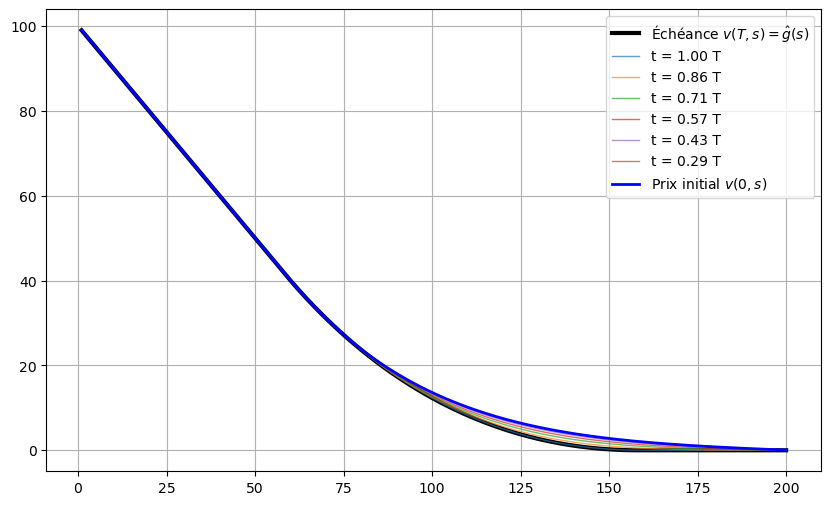

In [39]:
s, ghat, v0, snaps = solve_leland(
    100, 0.2, 0.05, 1, 1, 1.0, 200, 200, 120, nplots=6
)

plt.figure(figsize=(10,6))

# échéance en gras
plt.plot(s, ghat, 'k', lw=3, label="Échéance $v(T,s)=\hat g(s)$")

# profils intermédiaires
for i,vi in enumerate(snaps[1:]):
    plt.plot(s, vi, lw=1, alpha=0.7, label=f"t = {1-i/len(snaps):.2f} T")

plt.plot(s, v0, 'b', lw=2, label="Prix initial $v(0,s)$")

plt.legend()
plt.grid()
plt.show()


Computing ĝ...
Time stepping...


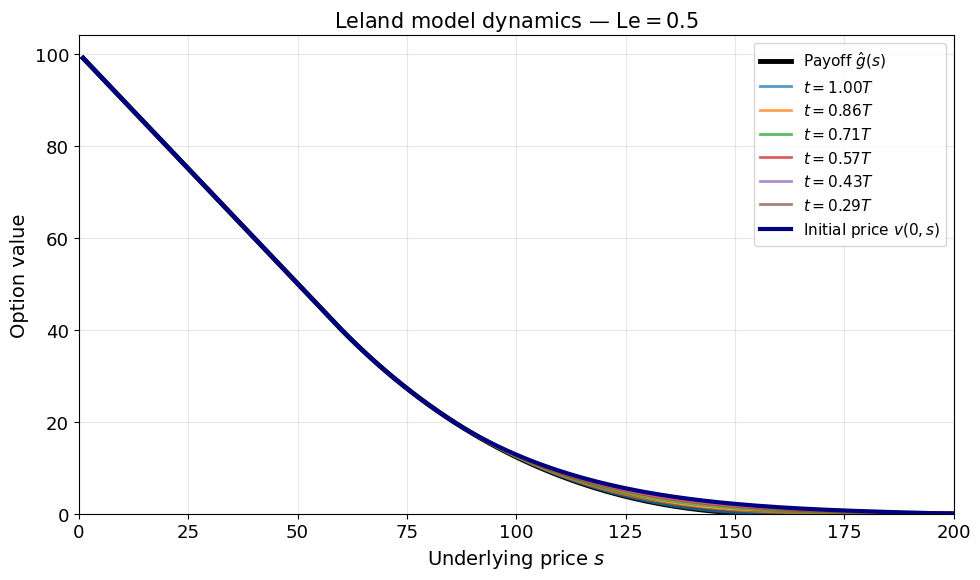

Computing ĝ...
Time stepping...


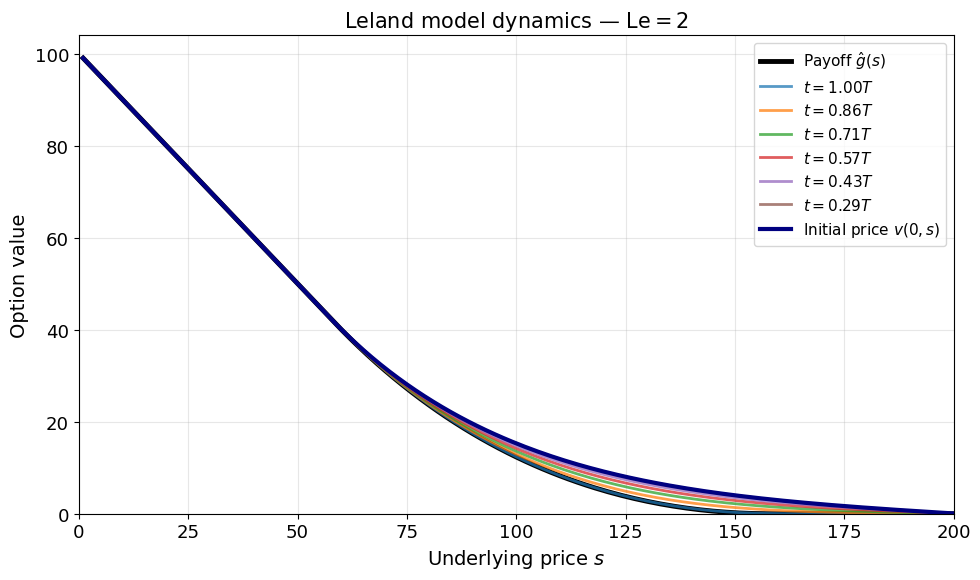

Computing ĝ...
Time stepping...


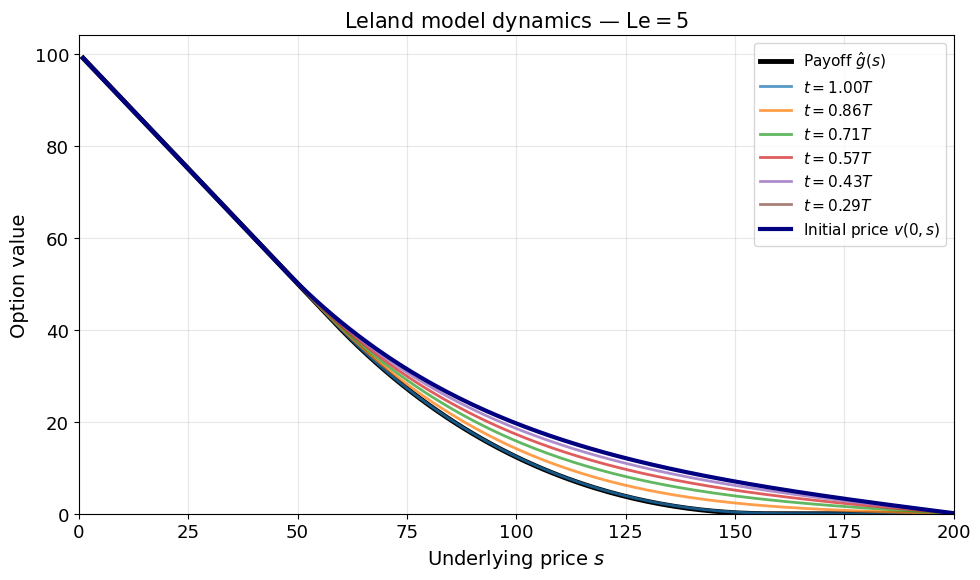

Computing ĝ...
Time stepping...


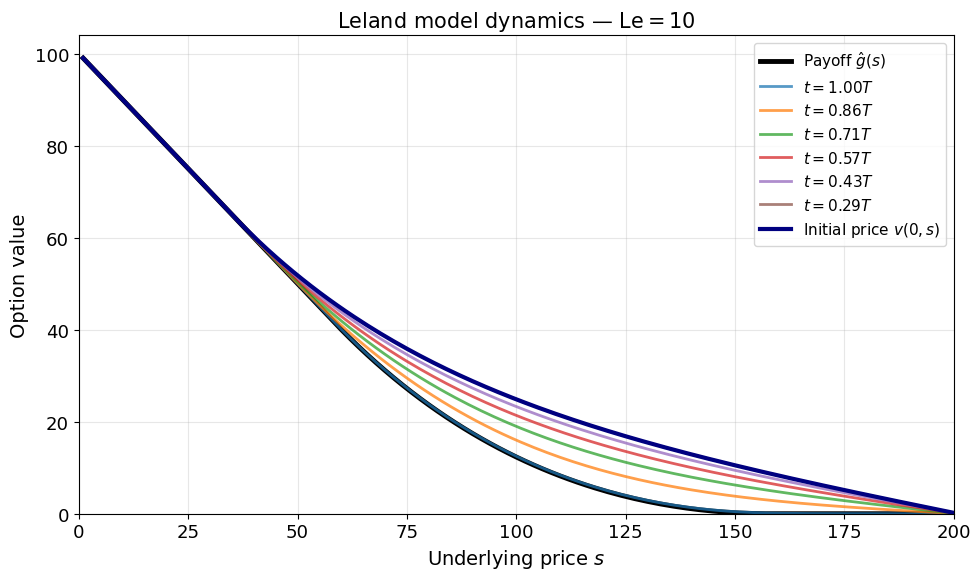

In [41]:

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "lines.linewidth": 2.0,
    "axes.grid": True,
    "grid.alpha": 0.3
})

Le_values = [0.5, 2, 5, 10]

for Le in Le_values:

    s, ghat, v0, snaps = solve_leland(
        K=100, sigma=0.2, r=0.05,
        Le=Le, Gamma=1, T=1.0,
        Smax=200, Ns=200, Nt=120, nplots=6
    )

    fig, ax = plt.subplots(figsize=(10,6))

    ax.plot(s, ghat, color="black", lw=3.5, label=r"Payoff $\hat g(s)$")

    for i,vi in enumerate(snaps[1:]):
        ax.plot(s, vi, alpha=0.75,
                label=rf"$t={(1-i/len(snaps)):.2f}T$")

    ax.plot(s, v0, color="navy", lw=3,
            label=r"Initial price $v(0,s)$")

    ax.set_title(rf"Leland model dynamics — $\mathrm{{Le}} = {Le}$")
    ax.set_xlabel("Underlying price $s$")
    ax.set_ylabel("Option value")

    ax.legend(frameon=True, fancybox=True)
    ax.set_xlim(0, s[-1])
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()
